# Credit Scoring Model

In [ ]:
# Importing all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

from sklearn.svm import SVC

In [ ]:
path = 'UCI_Credit_Card.csv'
df = pd.read_csv(path)

In [ ]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# Exploratory Data Analysis

In [ ]:
# Renommer la colonne directement
df.rename(columns={'default.payment.next.month': 'NextMonthDefault'}, inplace=True)

In [ ]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,NextMonthDefault
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


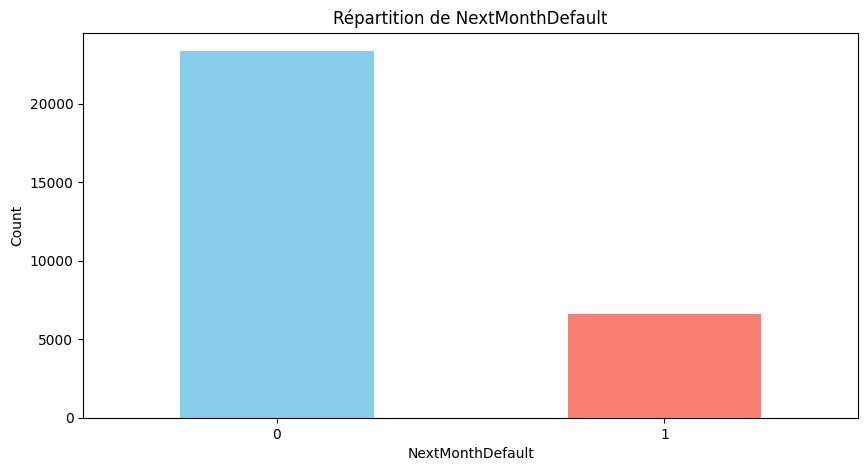

In [ ]:
# Utilisation directe de matplotlib pour un contrôle total
import matplotlib.pyplot as plt

df['NextMonthDefault'].value_counts().plot(kind='bar', figsize=(10, 5), color=['skyblue', 'salmon'])
plt.title('Répartition de NextMonthDefault')
plt.xlabel('NextMonthDefault')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
from collections import Counter

counts = Counter(df['NextMonthDefault'])
print(counts)

Counter({0: 23364, 1: 6636})


# **Independent Variable:**

## SEX

In [ ]:
df['SEX'].value_counts()

,count
SEX,
2,18112
1,11888


## Education

In [ ]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


In [ ]:
# Combine undefined categories (5, 6, 0) into "Others" (represented by 4)
df['EDUCATION'] = df['EDUCATION'].replace([5, 6, 0], 4)

In [ ]:
print(df['EDUCATION'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64


## Mariage

In [ ]:
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


In [ ]:

df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})  # Assuming "Others" is represented by category 3

In [ ]:
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,377


## Plotting our categorical features

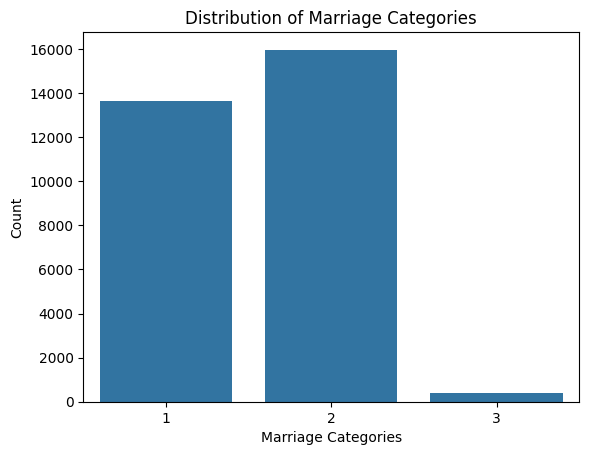

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Plotting the 'MARRIAGE' categorical feature
sns.countplot(x='MARRIAGE', data=df)
plt.title('Distribution of Marriage Categories')
plt.xlabel('Marriage Categories')
plt.ylabel('Count')
plt.show()

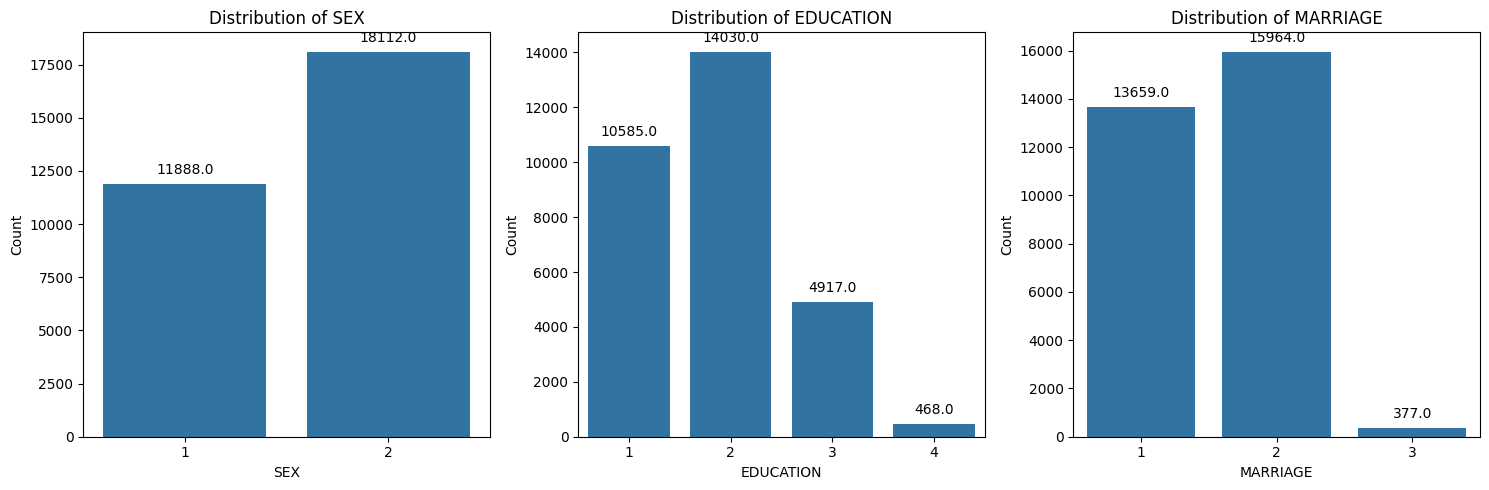

In [ ]:
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

fig, axes = plt.subplots(nrows=1, ncols=len(categorical_features), figsize=(15, 5))

for i, feature in enumerate(categorical_features):
    ax = sns.countplot(x=feature, data=df, ax=axes[i])
    for p in ax.patches:  # Ajouter des annotations sur chaque barre
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Dictionnaires pour mapper les valeurs
mapping_sex = {1: "Male", 2: "Female"}
mapping_education = {1: "Graduate School", 2: "University", 3: "High School", 4: "Others"}
mapping_marriage = {1: "Married", 2: "Single", 3: "Others"}

# Renommer les colonnes dans le DataFrame
df['SEX'] = df['SEX'].map(mapping_sex)
df['EDUCATION'] = df['EDUCATION'].map(mapping_education)
df['MARRIAGE'] = df['MARRIAGE'].map(mapping_marriage)


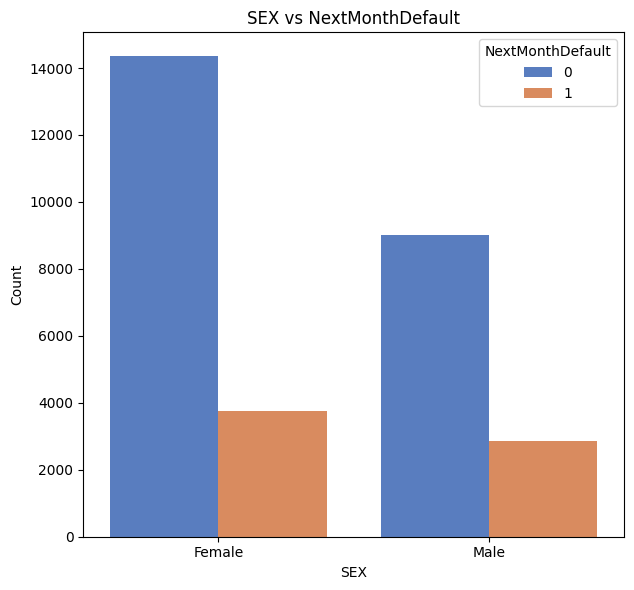

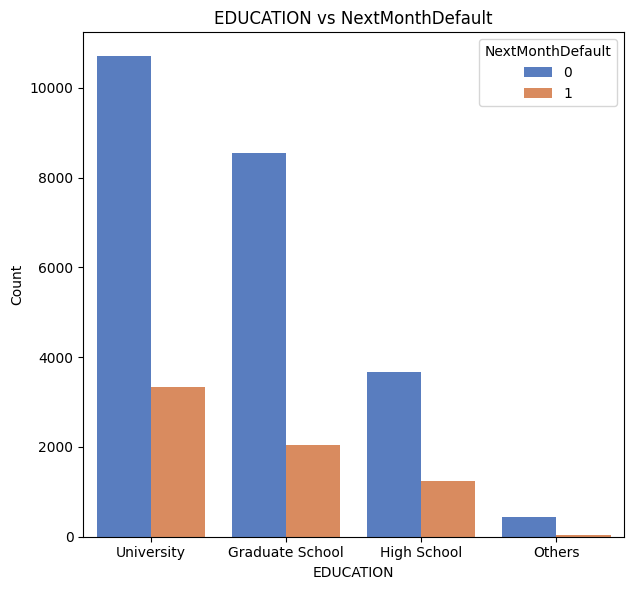

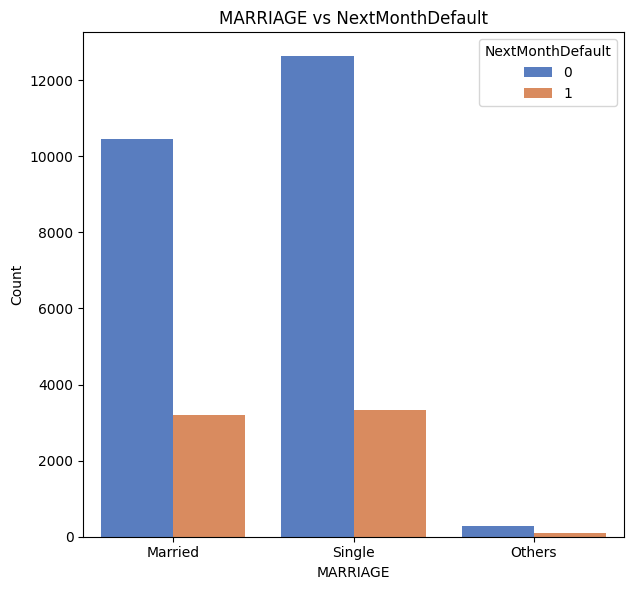

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Liste des variables catégorielles à analyser
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

# Création des visualisations
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    # Graphique 2 : Relation avec la variable cible 'IsDefaulter'
    plt.subplot(1, 2, 2)
    sns.countplot(x=feature, hue='NextMonthDefault', data=df, palette='muted')
    plt.title(f'{feature} vs NextMonthDefault')
    plt.xlabel(feature)
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

## Limit Balance

In [ ]:
df['LIMIT_BAL'].max()

1000000.0

  Cela signifie que la limite de crédit la plus élevée accordée aux clients est 1 000 000.

In [ ]:
df['LIMIT_BAL'].min()

10000.0

  Cela signifie que la plus petite limite de crédit accordée est 10 000.

In [ ]:
df['LIMIT_BAL'].describe()

,LIMIT_BAL
count,30000.000000
mean,167484.322667
std,129747.661567
min,10000.000000
25%,50000.000000
50%,140000.000000
75%,240000.000000
max,1000000.000000


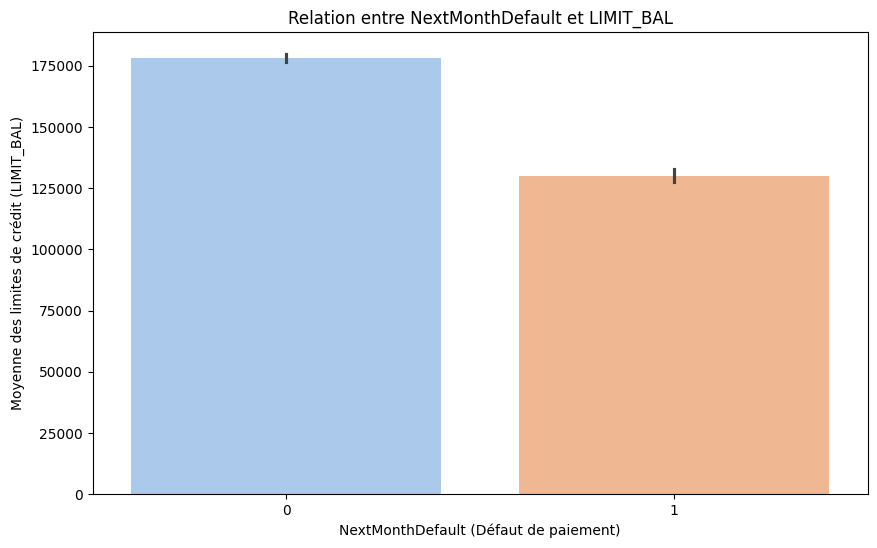

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Création du graphique en barres
plt.figure(figsize=(10, 6))
sns.barplot(x='NextMonthDefault', y='LIMIT_BAL', data=df, palette='pastel')
plt.title('Relation entre NextMonthDefault et LIMIT_BAL')
plt.xlabel('NextMonthDefault (Défaut de paiement)')
plt.ylabel('Moyenne des limites de crédit (LIMIT_BAL)')
plt.show()

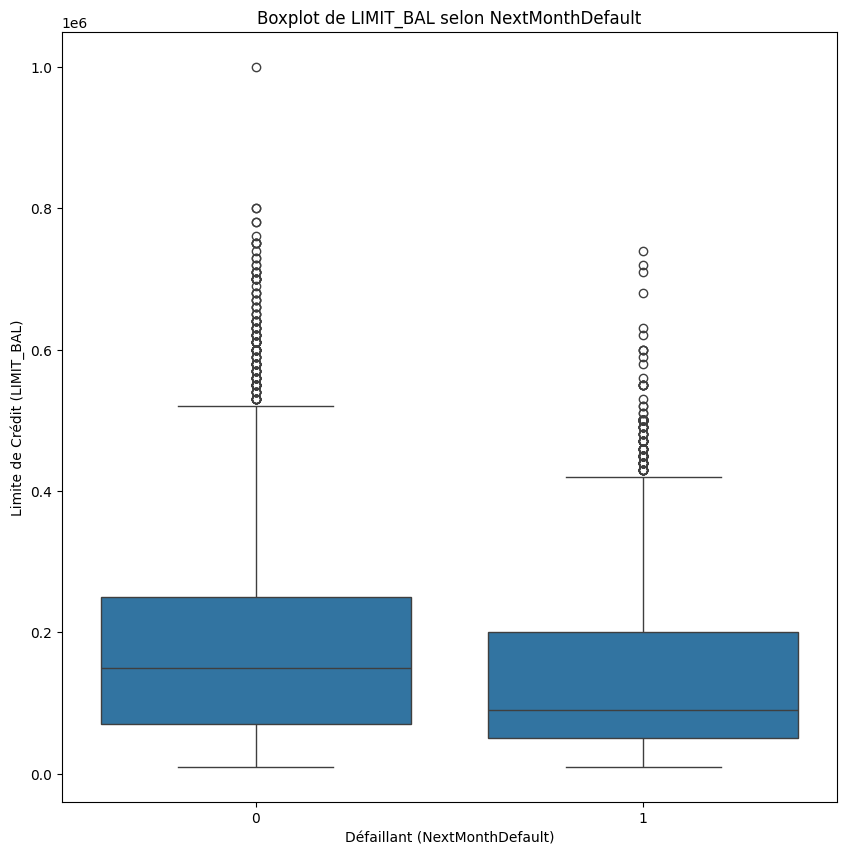

In [ ]:
plt.figure(figsize=(10,10))
ax = sns.boxplot(x="NextMonthDefault", y="LIMIT_BAL", data=df)
plt.xlabel("Défaillant (NextMonthDefault)")
plt.ylabel("Limite de Crédit (LIMIT_BAL)")
plt.title("Boxplot de LIMIT_BAL selon NextMonthDefault")
plt.show()

## AGE

In [ ]:
df['AGE'].value_counts()

,count
AGE,
29,1605
27,1477
28,1409
30,1395
26,1256
31,1217
25,1186
34,1162
32,1158


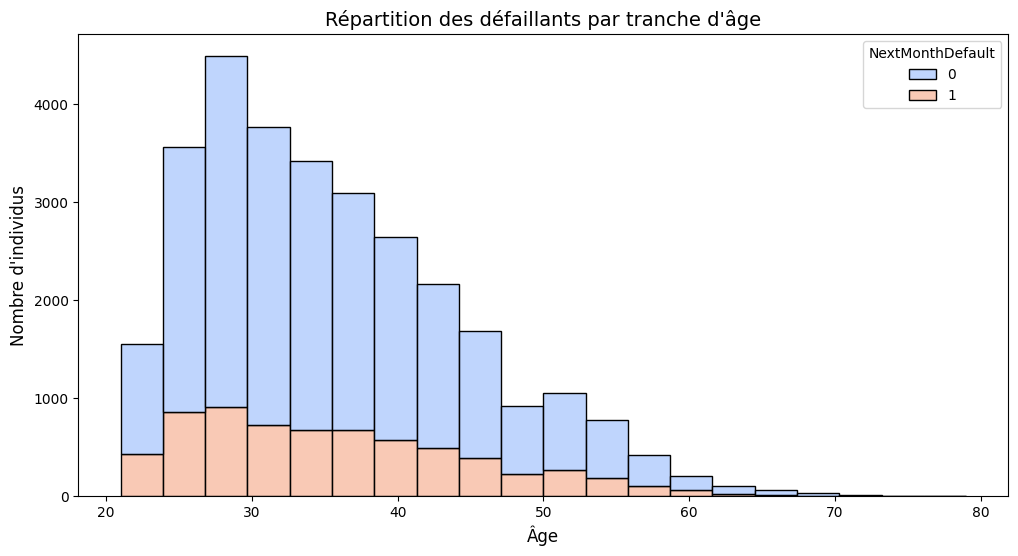

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assurez-vous que la colonne AGE est de type entier
df['AGE'] = df['AGE'].astype(int)

# Création du graphique en barres empilées
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='AGE', hue='NextMonthDefault', multiple='stack', bins=20, palette='coolwarm')

# Ajout de titres et labels
plt.title("Répartition des défaillants par tranche d'âge", fontsize=14)
plt.xlabel("Âge", fontsize=12)
plt.ylabel("Nombre d'individus", fontsize=12)

# Affichage du graphique
plt.show()


Interpretation:
Young adults (aged 25–40) hold the highest number of credit cards but exhibit a higher risk of default. In contrast, older individuals are fewer in number and have a lower default rate, suggesting greater financial stability.

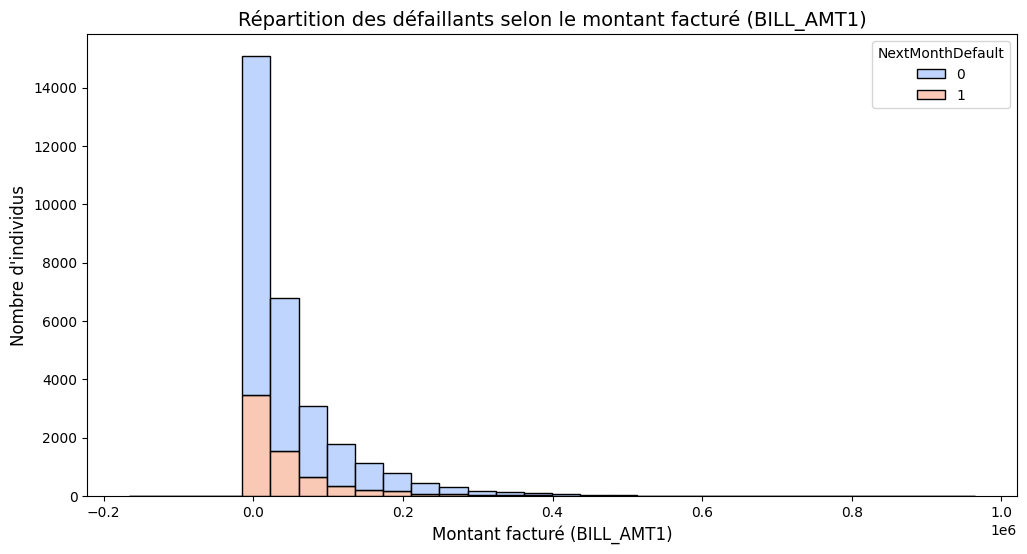

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Création de l'histogramme pour BILL_AMT1
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='BILL_AMT1', hue='NextMonthDefault', multiple='stack', bins=30, palette='coolwarm')

# Ajout des titres et labels
plt.title("Répartition des défaillants selon le montant facturé (BILL_AMT1)", fontsize=14)
plt.xlabel("Montant facturé (BILL_AMT1)", fontsize=12)
plt.ylabel("Nombre d'individus", fontsize=12)

# Affichage du graphique
plt.show()


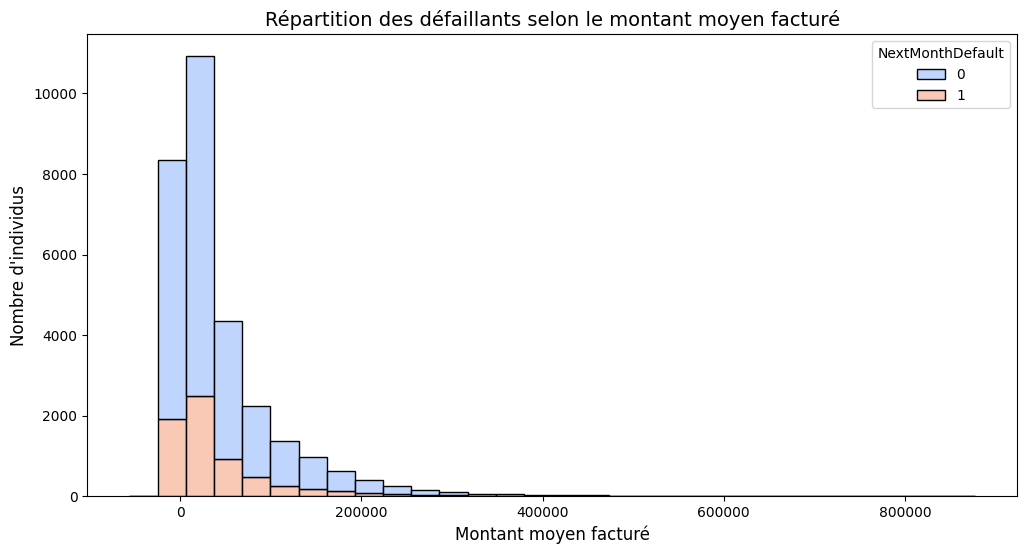

In [ ]:
df['BILL_AMT_MEAN'] = df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='BILL_AMT_MEAN', hue='NextMonthDefault', multiple='stack', bins=30, palette='coolwarm')

plt.title("Répartition des défaillants selon le montant moyen facturé", fontsize=14)
plt.xlabel("Montant moyen facturé", fontsize=12)
plt.ylabel("Nombre d'individus", fontsize=12)
plt.show()


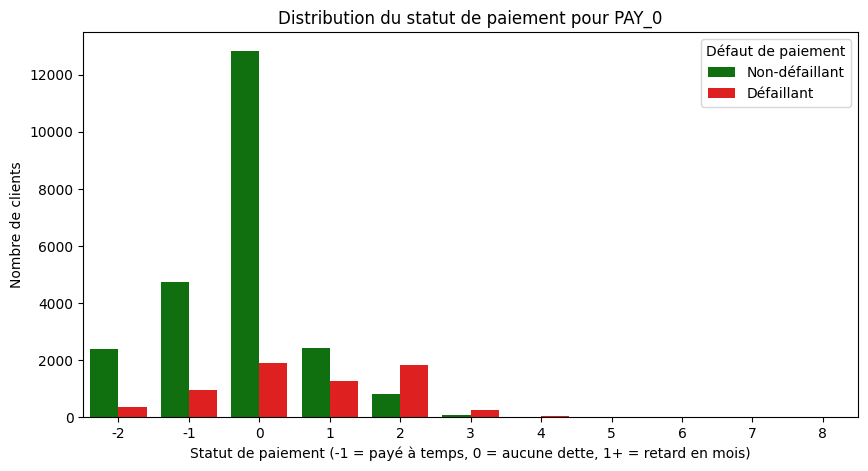

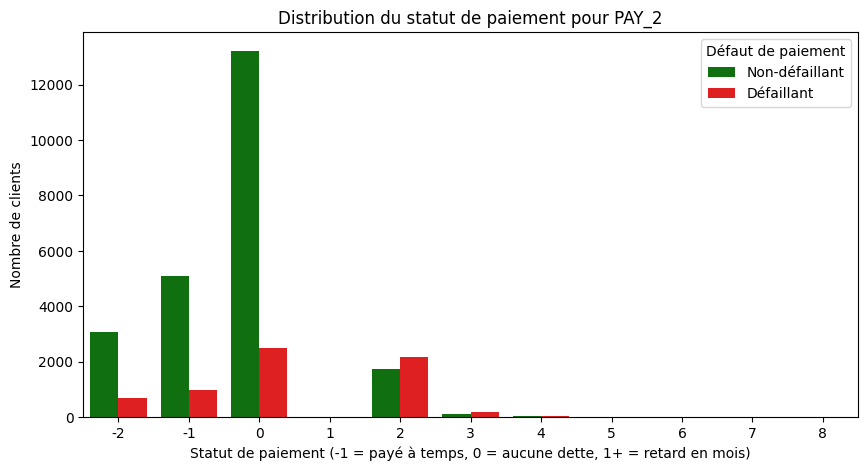

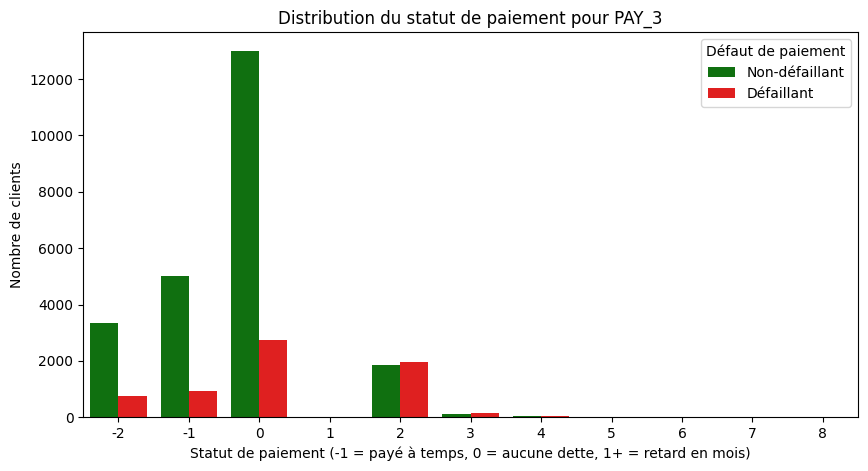

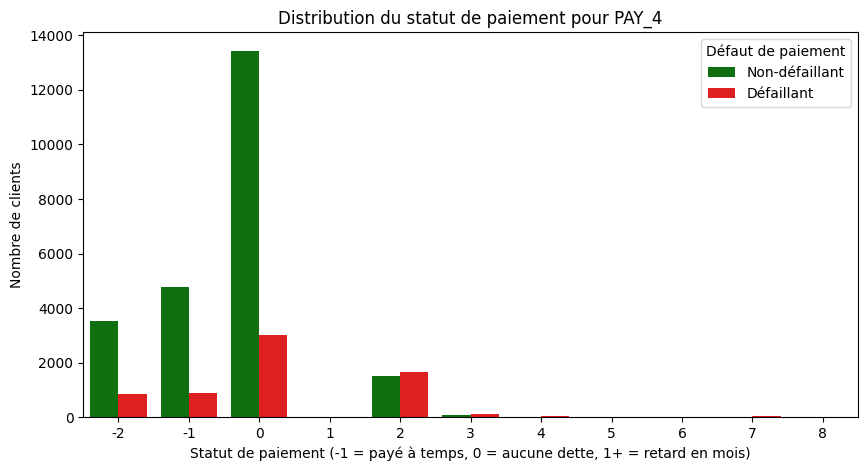

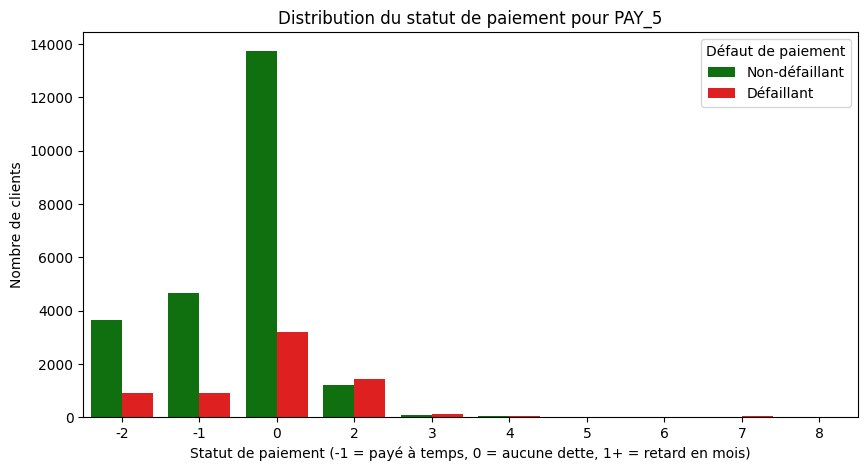

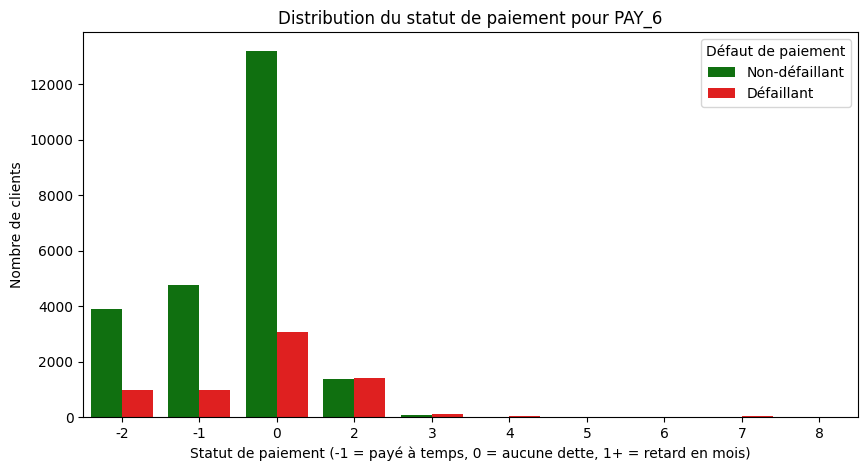

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des colonnes représentant les statuts de paiement mensuels
pay_col =  ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Affichage des distributions des retards par mois
for col in pay_col:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='NextMonthDefault', data=df, palette=['green', 'red'])

    plt.title(f"Distribution du statut de paiement pour {col}")
    plt.xlabel("Statut de paiement (-1 = payé à temps, 0 = aucune dette, 1+ = retard en mois)")
    plt.ylabel("Nombre de clients")
    plt.legend(title="Défaut de paiement", labels=["Non-défaillant", "Défaillant"])
    plt.show()


In [ ]:
print(df['NextMonthDefault'].value_counts(normalize=True))

NextMonthDefault
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [ ]:
print(df.dtypes)

ID                    int64
LIMIT_BAL           float64
SEX                  object
EDUCATION            object
MARRIAGE             object
AGE                   int64
PAY_0                 int64
PAY_2                 int64
PAY_3                 int64
PAY_4                 int64
PAY_5                 int64
PAY_6                 int64
BILL_AMT1           float64
BILL_AMT2           float64
BILL_AMT3           float64
BILL_AMT4           float64
BILL_AMT5           float64
BILL_AMT6           float64
PAY_AMT1            float64
PAY_AMT2            float64
PAY_AMT3            float64
PAY_AMT4            float64
PAY_AMT5            float64
PAY_AMT6            float64
NextMonthDefault      int64
BILL_AMT_MEAN       float64
dtype: object


In [ ]:
required_columns = ['EDUCATION', 'MARRIAGE']
for col in required_columns:
    if col not in df.columns:
        print(f"La colonne {col} est manquante.")

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Encodage des variables catégoriques binaires
encoder = LabelEncoder()
df['SEX'] = encoder.fit_transform(df['SEX'])  # Par exemple : 'Female' -> 0, 'Male' -> 1

# Encodage one-hot pour les colonnes multi-catégoriques
df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], drop_first=True)  # Evite les duplications

In [ ]:
# Afficher les valeurs uniques de la colonne encodée
print(df['SEX'].unique())  # Exemple : [0, 1]

[0 1]


In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,NextMonthDefault,BILL_AMT_MEAN,EDUCATION_High School,EDUCATION_Others,EDUCATION_University,MARRIAGE_Others,MARRIAGE_Single
0,1,20000.0,0,24,2,2,-1,-1,-2,-2,...,0.0,0.0,0.0,1,1284.000000,False,False,True,False,False
1,2,120000.0,0,26,-1,2,0,0,0,2,...,1000.0,0.0,2000.0,1,2846.166667,False,False,True,False,True
2,3,90000.0,0,34,0,0,0,0,0,0,...,1000.0,1000.0,5000.0,0,16942.166667,False,False,True,False,True
3,4,50000.0,0,37,0,0,0,0,0,0,...,1100.0,1069.0,1000.0,0,38555.666667,False,False,True,False,False
4,5,50000.0,1,57,-1,0,-1,0,0,0,...,9000.0,689.0,679.0,0,18223.166667,False,False,True,False,False


In [ ]:
print(df.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'NextMonthDefault', 'BILL_AMT_MEAN',
       'EDUCATION_High School', 'EDUCATION_Others', 'EDUCATION_University',
       'MARRIAGE_Others', 'MARRIAGE_Single'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['NextMonthDefault', 'ID'])  # Exclure 'ID' et la cible
y = df['NextMonthDefault']  # Cible

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Matrice de confusion :
[[6652  388]
 [1315  645]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      7040
           1       0.62      0.33      0.43      1960

    accuracy                           0.81      9000
   macro avg       0.73      0.64      0.66      9000
weighted avg       0.79      0.81      0.79      9000



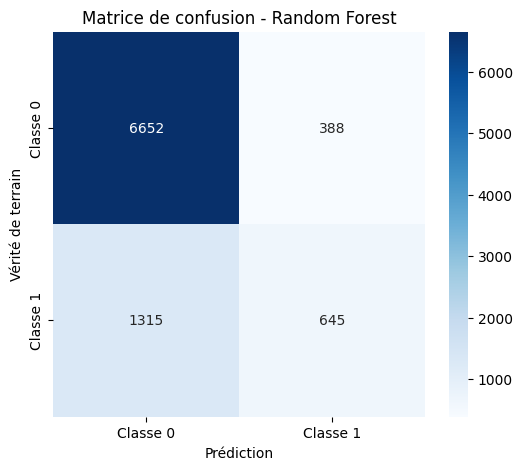

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Fonction pour afficher la matrice de confusion
def plot_conf_matrix(conf_matrix, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["Classe 0", "Classe 1"], yticklabels=["Classe 0", "Classe 1"])
    plt.title(f'Matrice de confusion - {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité de terrain')
    plt.show()

# Modèle avec pondération automatique des classes
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

# Rapport de classification
class_report = classification_report(y_test, y_pred)
print("\nRapport de classification :")
print(class_report)

# Affichage de la matrice de confusion et du rapport de classification
plot_conf_matrix(conf_matrix, "Random Forest")


Matrice de confusion :
[[5841 1199]
 [ 843 1117]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7040
           1       0.48      0.57      0.52      1960

    accuracy                           0.77      9000
   macro avg       0.68      0.70      0.69      9000
weighted avg       0.79      0.77      0.78      9000



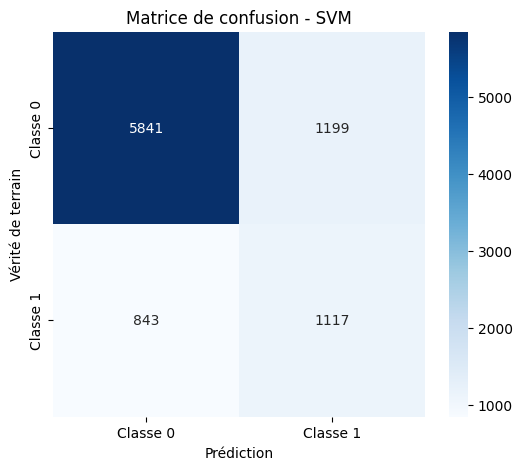

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Fonction pour afficher la matrice de confusion
def plot_conf_matrix(conf_matrix, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["Classe 0", "Classe 1"], yticklabels=["Classe 0", "Classe 1"])
    plt.title(f'Matrice de confusion - {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité de terrain')
    plt.show()

# Pipeline : mise à l'échelle + SVM
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', random_state=42)
)

# Entraînement
svm_model.fit(X_train, y_train)

# Prédiction
y_pred = svm_model.predict(X_test)

# Matrice de confusion et rapport de classification
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nRapport de classification :")
print(class_report)

# Affichage de la matrice de confusion et du rapport de classification
plot_conf_matrix(conf_matrix, "SVM")


Matrice de confusion :
[[5730 1310]
 [ 861 1099]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      7040
           1       0.46      0.56      0.50      1960

    accuracy                           0.76      9000
   macro avg       0.66      0.69      0.67      9000
weighted avg       0.78      0.76      0.77      9000



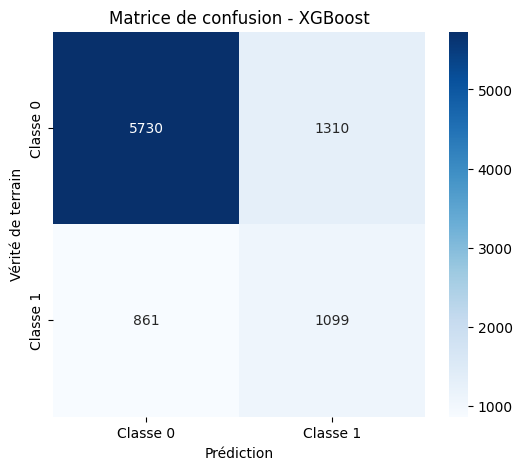

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Fonction pour afficher la matrice de confusion
def plot_conf_matrix(conf_matrix, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["Classe 0", "Classe 1"], yticklabels=["Classe 0", "Classe 1"])
    plt.title(f'Matrice de confusion - {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité de terrain')
    plt.show()

# Étape 1 : Calculer le poids de la classe minoritaire
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

# Étape 2 : Créer le modèle
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Entraînement
xgb_model.fit(X_train, y_train)

# Prédictions
y_pred = xgb_model.predict(X_test)

# Matrice de confusion et rapport de classification
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nRapport de classification :")
print(class_report)

# Affichage de la matrice de confusion et du rapport de classification
plot_conf_matrix(conf_matrix, "XGBoost")


Matrice de confusion :
[[4939 2101]
 [ 705 1255]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      7040
           1       0.37      0.64      0.47      1960

    accuracy                           0.69      9000
   macro avg       0.62      0.67      0.63      9000
weighted avg       0.77      0.69      0.71      9000



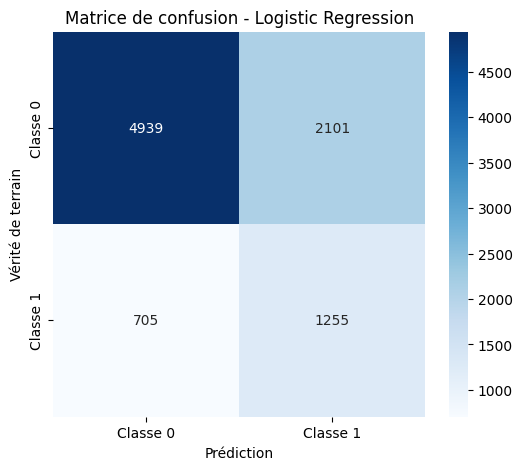

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Fonction pour afficher la matrice de confusion
def plot_conf_matrix(conf_matrix, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["Classe 0", "Classe 1"], yticklabels=["Classe 0", "Classe 1"])
    plt.title(f'Matrice de confusion - {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité de terrain')
    plt.show()

# Pipeline avec mise à l'échelle (important pour LogisticRegression)
logreg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

# Entraînement
logreg_model.fit(X_train, y_train)

# Prédictions
y_pred = logreg_model.predict(X_test)

# Matrice de confusion et rapport de classification
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nRapport de classification :")
print(class_report)

# Affichage de la matrice de confusion et du rapport de classification
plot_conf_matrix(conf_matrix, "Logistic Regression")


Matrice de confusion :
[[6625  415]
 [1334  626]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      7040
           1       0.60      0.32      0.42      1960

    accuracy                           0.81      9000
   macro avg       0.72      0.63      0.65      9000
weighted avg       0.78      0.81      0.78      9000



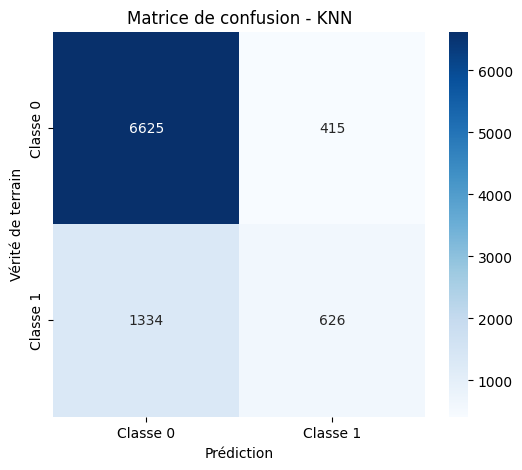

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Fonction pour afficher la matrice de confusion
def plot_conf_matrix(conf_matrix, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["Classe 0", "Classe 1"], yticklabels=["Classe 0", "Classe 1"])
    plt.title(f'Matrice de confusion - {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité de terrain')
    plt.show()

# Pipeline : normalisation + KNN
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=9)
)

# Entraînement
knn_model.fit(X_train, y_train)

# Prédictions
y_pred = knn_model.predict(X_test)

# Matrice de confusion et rapport de classification
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nRapport de classification :")
print(class_report)

# Affichage de la matrice de confusion et du rapport de classification
plot_conf_matrix(conf_matrix, "KNN")


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Liste des modèles et leurs résultats
models = {
    'RandomForest': model,  # Remplacer par ton modèle déjà entraîné
    'SVM': svm_model,       # Remplacer par ton modèle déjà entraîné
    'XGBoost': xgb_model,   # Remplacer par ton modèle déjà entraîné
    'LogisticRegression': logreg_model,  # Remplacer par ton modèle déjà entraîné
    'KNN': knn_model        # Remplacer par ton modèle déjà entraîné
}

# Dictionnaire pour stocker les résultats
results = {}

# Calculer l'accuracy de chaque modèle
for model_name, model in models.items():
    y_pred = model.predict(X_test)  # Prédictions sur le jeu de test
    accuracy = accuracy_score(y_test, y_pred)  # Calcul de l'accuracy
    results[model_name] = accuracy

# Créer un DataFrame avec les résultats
accuracy_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

# Afficher le tableau
print(accuracy_df)


                Model  Accuracy
0        RandomForest  0.810778
1                 SVM  0.773111
2             XGBoost  0.758778
3  LogisticRegression  0.688222
4                 KNN  0.805667


# Amélioration des résultats

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Définir les paramètres à tester
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['auto', 'sqrt', 'log2']
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
                                   param_distributions=param_dist,
                                   n_iter=10,  # Nombre d'essais aléatoires
                                   cv=3,
                                   n_jobs=-1,
                                   verbose=2,
                                   random_state=42)

random_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres et score
print("Meilleurs paramètres : ", random_search.best_params_)
print("Meilleure précision : ", random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres :  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 513}
Meilleure précision :  0.8063333333333333


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Définir les hyperparamètres à tester
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Création du GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
                           param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Exécution de la recherche sur les données d'entraînement
grid_search.fit(X_train, y_train)

# Meilleurs hyperparamètres
print("Meilleurs paramètres :", grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Meilleurs paramètres : {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Utiliser le meilleur modèle trouvé
y_pred = best_model.predict(X_test)

# Afficher la matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# Afficher le rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

# Afficher la précision
accuracy = best_model.score(X_test, y_test)
print(f"\nPrécision (Accuracy) du modèle optimisé : {accuracy:.4f}")


Matrice de confusion :
[[6661  379]
 [1299  661]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7040
           1       0.64      0.34      0.44      1960

    accuracy                           0.81      9000
   macro avg       0.74      0.64      0.66      9000
weighted avg       0.79      0.81      0.79      9000


Précision (Accuracy) du modèle optimisé : 0.8136


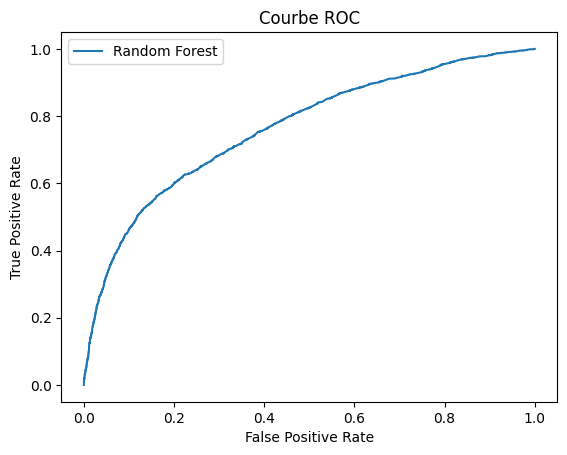

ROC AUC Score : 0.7644984925788498


In [ ]:
# Calcul de la courbe ROC
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilités pour la classe 1
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

# Calcul du ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score : {roc_auc}")

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Définir le modèle Random Forest
model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Effectuer une validation croisée avec 5 plis
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

# Afficher les scores de validation croisée
print(f"Scores de validation croisée : {cv_scores}")
print(f"Précision moyenne (validation croisée) : {cv_scores.mean():.4f}")


Scores de validation croisée : [0.81761905 0.82047619 0.81904762 0.81666667 0.81190476]
Précision moyenne (validation croisée) : 0.8171


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Afficher la matrice de confusion
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

# Afficher le rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))


Matrice de confusion :
[[6661  379]
 [1299  661]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7040
           1       0.64      0.34      0.44      1960

    accuracy                           0.81      9000
   macro avg       0.74      0.64      0.66      9000
weighted avg       0.79      0.81      0.79      9000



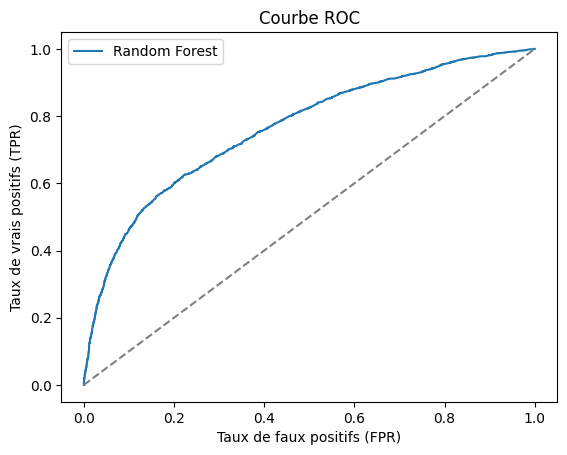

Score AUC : 0.7645


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])

# Affichage de la courbe ROC
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonale (modèle aléatoire)
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend()
plt.show()

# Score AUC
auc_score = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
print(f"Score AUC : {auc_score:.4f}")


In [ ]:
import pickle
with open('credit_scoring_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)
